[
!
[
O
p
e
n
 
i
n
 
C
o
l
a
b
]
(
h
t
t
p
s
:
/
/
c
o
l
a
b
.
r
e
s
e
a
r
c
h
.
g
o
o
g
l
e
.
c
o
m
/
a
s
s
e
t
s
/
c
o
l
a
b
-
b
a
d
g
e
.
s
v
g
)
]
(
h
t
t
p
s
:
/
/
c
o
l
a
b
.
r
e
s
e
a
r
c
h
.
g
o
o
g
l
e
.
c
o
m
/
g
i
t
h
u
b
/
p
a
c
h
t
e
r
l
a
b
/
O
P
_
2
0
2
5
/
b
l
o
b
/
m
a
i
n
/
a
n
a
l
y
s
i
s
_
s
c
r
i
p
t
s
/
4
_
R
a
t
_
I
n
d
i
v
i
d
u
a
l
_
O
v
e
r
v
i
e
w
.
i
p
y
n
b
)

# Clone github repo

In [ ]:
!git clone https://github.com/pachterlab/OP_2025.git
%cd /content/OP_2025/

# Download Data

In [ ]:
!mkdir omics_adata
!wget -O omics_data/rat_RNA_meta.h5ad https://data.caltech.edu/records/j57wp-0pp06/files/rat_RNA_meta.h5ad?download=1
!wget -O omics_data/rat_ACETYL_meta.h5ad https://data.caltech.edu/records/j57wp-0pp06/files/rat_ACETYL_meta.h5ad?download=1
!wget -O omics_data/rat_ATAC_meta.h5ad https://data.caltech.edu/records/j57wp-0pp06/files/rat_ATAC_meta.h5ad?download=1
!wget -O omics_data/rat_IMMUNO_meta.h5ad https://data.caltech.edu/records/j57wp-0pp06/files/rat_IMMUNO_meta.h5ad?download=1
!wget -O omics_data/rat_METAB_meta.h5ad https://data.caltech.edu/records/j57wp-0pp06/files/rat_METAB_meta.h5ad?download=1
!wget -O omics_data/rat_METHYL_meta.h5ad https://data.caltech.edu/records/j57wp-0pp06/files/rat_METHYL_meta.h5ad?download=1
!wget -O omics_data/rat_PHOSPHO_meta.h5ad https://data.caltech.edu/records/j57wp-0pp06/files/rat_PHOSPHO_meta.h5ad?download=1
!wget -O omics_data/rat_PROT_meta.h5ad https://data.caltech.edu/records/j57wp-0pp06/files/rat_PROT_meta.h5ad?download=1
!wget -O omics_data/rat_UBIQ_meta.h5ad https://data.caltech.edu/records/j57wp-0pp06/files/rat_UBIQ_meta.h5ad?download=1
!cd analysis_scripts/

# Install Packages

In [ ]:
!pip install -qr requirements.txt 

In [1]:
# import packages

import sys, os
sys.path.append('analysis_scripts')

# numbers
import numpy as np
import pandas as pd

# sc
import scanpy as sc

# plots
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from rat_friend import *

In [2]:
os.chdir('../')

# Color Loading

In [3]:
tissue_colors, sex_colors = get_color_palettes()
color_dict = {**sex_colors, **tissue_colors}

# Collect Metadata from all OMIC files

In [4]:
omic_list =  ['RNA', 'ATAC', 'METHYL', 'ACETYL', 'PROT', 'PHOSPHO', 'UBIQ', 'METAB', 'IMMUNO']
for omic in omic_list:
    print(omic)
    adata = load_annotated_omic(f'omics_data/rat_{omic}_meta.h5ad', omic)
    if omic in ['RNA']:
        omic_pheno = adata.obs[['nid', 'tissue']].copy()
        omic_pheno[omic] = 1
    else:
        temp_meta = adata.obs.reset_index(drop=True)[['nid', 'tissue']]
        temp_meta.tissue = temp_meta.tissue.str.upper()
        temp_meta[omic] = 1
        omic_pheno = pd.merge(omic_pheno, temp_meta, how = 'outer', on = ['nid', 'tissue'])
omic_pheno = omic_pheno.fillna(0)
omic_pheno = omic_pheno.replace(['TESTES', 'OVARY'], 'TESTES/OVARY')
omic_pheno

RNA
ATAC
METHYL
ACETYL
PROT
PHOSPHO
UBIQ
METAB
IMMUNO


,nid,tissue,RNA,ATAC,METHYL,ACETYL,PROT,PHOSPHO,UBIQ,METAB,IMMUNO
0,F0A,ADRNL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,F0A,BAT,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
2,F0A,BLOOD,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,F0A,COLON,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,F0A,CORTEX,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1060,M8L,ADRNL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1061,M8L,BAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1062,M8L,PLASMA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1063,M8M,BAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Compress to by-individual

In [5]:
sum_omic_pheno = omic_pheno[['nid']+omic_list].groupby(['nid'], observed=True).sum().reset_index()#/18

sum_omic_pheno = sum_omic_pheno[sum_omic_pheno.RNA > 0].reset_index(drop=True)
sum_omic_pheno.sort_values(['nid'])

,nid,RNA,ATAC,METHYL,ACETYL,PROT,PHOSPHO,UBIQ,METAB,IMMUNO
0,F0A,18.0,8.0,8.0,2.0,6.0,6.0,2.0,18.0,16.0
1,F0C,18.0,8.0,8.0,2.0,7.0,7.0,2.0,18.0,16.0
2,F0E,16.0,8.0,8.0,2.0,6.0,6.0,2.0,18.0,16.0
3,F0K,18.0,8.0,8.0,2.0,7.0,7.0,2.0,18.0,16.0
4,F0L,17.0,8.0,8.0,2.0,7.0,7.0,2.0,18.0,16.0
5,F1A,17.0,8.0,8.0,1.0,6.0,6.0,2.0,18.0,16.0
6,F1F,16.0,8.0,8.0,2.0,7.0,7.0,2.0,18.0,16.0
7,F1I,17.0,8.0,8.0,2.0,7.0,7.0,2.0,18.0,16.0
8,F1L,17.0,8.0,8.0,2.0,7.0,7.0,1.0,18.0,16.0
9,F1N,16.0,8.0,8.0,2.0,7.0,7.0,2.0,18.0,16.0


## Plot Results by individual

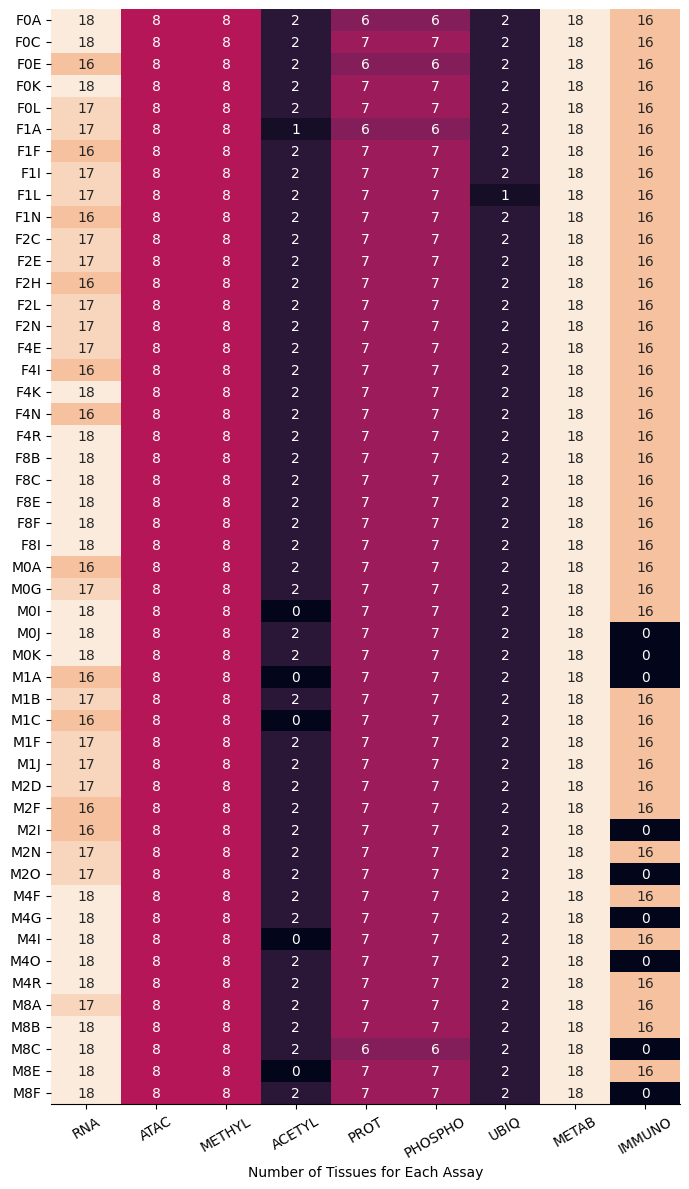

In [6]:
plt.figure(figsize=(7, 12))
#plt.figure(figsize=(25, 25))
g = sns.heatmap(sum_omic_pheno.sort_values(['nid'])[
            omic_list], 
            cbar = False,
            yticklabels = sum_omic_pheno.sort_values(['nid'])[
            'nid'],
           annot = True)
sns.despine(left=True)
plt.xticks(rotation=30)
plt.xlabel('Number of Tissues for Each Assay')
plt.tight_layout()
plt.savefig('figures_final/fig_1ab.png', pad_inches=0)

## Plot results by Tissue

In [7]:
sum_tissue_pheno = omic_pheno[['tissue', 'nid']+omic_list]

df1 = sum_tissue_pheno[[x[0] == 'M' for x in sum_tissue_pheno.nid.values]]
df1 = df1.drop('nid', axis=1).groupby(['tissue'], observed=True).sum().reset_index()#/18
df1 = df1[df1.RNA > 0].reset_index(drop=True).add_suffix('_F')

df2 = sum_tissue_pheno[[x[0] == 'F' for x in sum_tissue_pheno.nid.values]]
df2 = df2.drop('nid', axis=1).groupby(['tissue'], observed=True).sum().reset_index()#/18
df2 = df2[df2.RNA > 0].reset_index(drop=True).add_suffix('_M')

df3 = pd.concat([df1, df2], axis=1)
df3 = df3[[item for items in zip(df1.columns, df2.columns) for item in items]]
df3

,tissue_F,tissue_M,RNA_F,RNA_M,ATAC_F,ATAC_M,METHYL_F,METHYL_M,ACETYL_F,ACETYL_M,PROT_F,PROT_M,PHOSPHO_F,PHOSPHO_M,UBIQ_F,UBIQ_M,METAB_F,METAB_M,IMMUNO_F,IMMUNO_M
0,ADRNL,ADRNL,25.0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,28.0,24.0,33.0
1,BAT,BAT,25.0,24.0,25.0,25.0,25.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,28.0,21.0,29.0
2,BLOOD,BLOOD,25.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,COLON,COLON,24.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,25.0,16.0,25.0
4,CORTEX,CORTEX,24.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,30.0,0.0,0.0,26.0,28.0,19.0,29.0
5,HEART,HEART,25.0,24.0,25.0,25.0,25.0,25.0,24.0,30.0,30.0,30.0,30.0,30.0,30.0,29.0,26.0,28.0,19.0,29.0
6,HIPPOC,HIPPOC,25.0,24.0,25.0,25.0,25.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,25.0,16.0,25.0
7,HYPOTH,HYPOTH,24.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,25.0,0.0,0.0
8,KIDNEY,KIDNEY,24.0,25.0,25.0,25.0,25.0,25.0,0.0,0.0,30.0,30.0,30.0,30.0,0.0,0.0,26.0,28.0,19.0,29.0
9,LIVER,LIVER,24.0,25.0,25.0,25.0,25.0,25.0,24.0,29.0,30.0,29.0,30.0,29.0,30.0,30.0,26.0,28.0,19.0,29.0


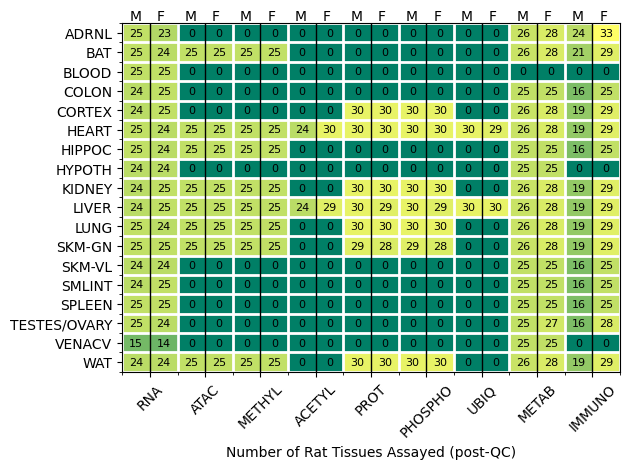

In [8]:
# Arrange alternate columns with data from channel S and A
data = np.array(df3)[:, 2:].astype('int')

x = df3.columns[2:].tolist()
y = df3['tissue_F'].tolist()

fig, ax = plt.subplots()
im = ax.imshow(data, cmap='summer')

# set xlabels
ax.set_xticks(list(np.arange(0.5, len(x)+.5, 2)))
ax.set_xticklabels([x[:-2] for x in x][::2], rotation=45)

# set ylabels
ax.set_yticks(list(range(0, len(y), 1)))
ax.set_yticklabels(y)

# white grid
ax.set_xticks(np.arange(-0.5, len(x), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(y), 1), minor=True)
ax.grid(which='minor', axis='both', 
linestyle='-', color='white', linewidth=2)

for i in range(0, len(x), 2):
    ax.text(-0.25 + i , -0.65, "M")
    ax.axvline(i + 0.5, lw=1, color='black', linewidth=0.7)
    ax.text(0.75 + i , -0.65, "F")

for i in range(len(x)):
    for j in range(len(y)):
        text = ax.text(j, i, data[i, j],
                       ha="center", va="center", color="black", size = 8)

ax.set_aspect('auto')
plt.xlabel('Number of Rat Tissues Assayed (post-QC)')
plt.subplots_adjust(hspace=0, wspace=0)
plt.tight_layout()
plt.savefig(f'figures_final/supp_fig_1.png')

# Plot RNA results by individual

In [39]:
rna_df = omic_pheno[['nid', 'tissue', 'RNA']].pivot(index='nid', columns='tissue', values='RNA').reset_index()
rna_df.columns.name=None
rna_df = rna_df[rna_df.nid.isin(sum_omic_pheno['nid'])]
rna_df

,nid,ADRNL,BAT,BLOOD,COLON,CORTEX,HEART,HIPPOC,HYPOTH,KIDNEY,LIVER,LUNG,PLASMA,SKM-GN,SKM-VL,SMLINT,SPLEEN,TESTES/OVARY,VENACV,WAT
0,F0A,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,F0C,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,F0E,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
5,F0K,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
6,F0L,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
7,F1A,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
8,F1F,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
9,F1I,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
11,F1L,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
12,F1N,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0


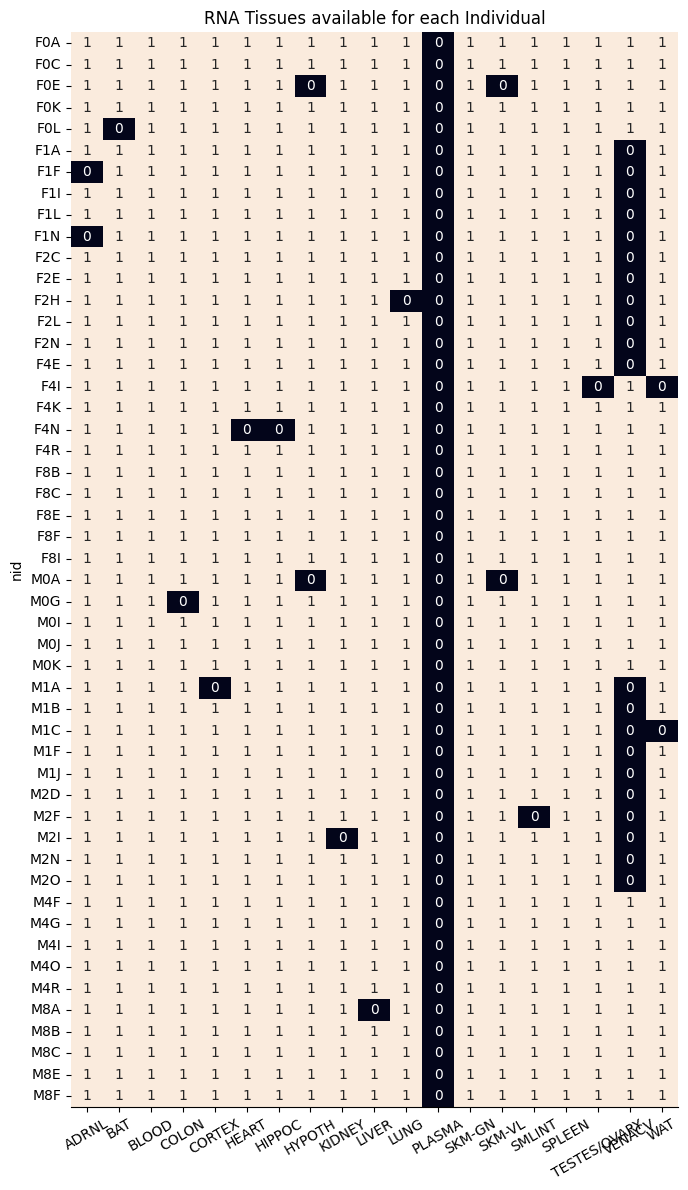

In [41]:
plt.figure(figsize=(7, 12))
#plt.figure(figsize=(25, 25))
g = sns.heatmap(rna_df.set_index('nid').fillna(0),
            cbar = False,
            yticklabels = rna_df['nid'],
           annot = True)
sns.despine(left=True)
plt.xticks(rotation=30)
plt.title('RNA Tissues available for each Individual')
plt.tight_layout()
plt.savefig('figures_final/supp_fig_2.png', pad_inches=0)